# JavaScript DOM


Q1. Explain the DOM and its role in Web development.

In [ ]:
<!DOCTYPE html>
<html>
<head>
    <title>DOM Demo</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 40px; line-height: 1.6; }
        .demo { border: 2px solid #007bff; padding: 20px; margin: 20px 0; border-radius: 8px; }
        .live-dom { background: #f8f9fa; padding: 15px; font-family: monospace; min-height: 100px; }
        button { padding: 10px 20px; margin: 5px; cursor: pointer; font-size: 14px; }
        .highlight { background: #fff3cd; padding: 5px; border-radius: 3px; }
    </style>
</head>
<body>
    <h1>🌳 DOM (Document Object Model) Demo</h1>

    <div class="demo">
        <h3>📄 Original HTML:</h3>
        <div id="original-html" class="live-dom">
            <h2 id="title">Dynamic Title</h2>
            <p id="content">Original content here...</p>
            <button id="btn">Click me!</button>
        </div>
    </div>

    <div class="demo">
        <h3>⚡ Live DOM Manipulation:</h3>
        <button onclick="changeTitle()">📝 Change Title</button>
        <button onclick="addElement()">➕ Add Paragraph</button>
        <button onclick="removeElement()">🗑️ Remove Button</button>
        <button onclick="toggleClass()">🎨 Toggle Style</button>
        <button onclick="showTree()">🌳 Show DOM Tree</button>
        <button onclick="resetDemo()">🔄 Reset</button>
    </div>

    <div class="demo">
        <h3>🔍 DOM Properties:</h3>
        <div id="properties" class="live-dom"></div>
    </div>

    <script>
        const title = document.getElementById('title');
        const content = document.getElementById('content');
        const btn = document.getElementById('btn');

        function log(message) {
            console.log(`DOM: ${message}`);
        }

        // 1️⃣ Change Text Content
        function changeTitle() {
            title.textContent = 'DOM Changed Me!';
            log('textContent updated');
        }

        // 2️⃣ Create & Append Element
        function addElement() {
            const newP = document.createElement('p');
            newP.textContent = '🆕 New paragraph added dynamically!';
            newP.style.color = 'blue';
            content.parentNode.appendChild(newP);
            log('Element created & appended');
        }

        // 3️⃣ Remove Element
        function removeElement() {
            if (btn) {
                btn.parentNode.removeChild(btn);
                log('Button removed from DOM');
            }
        }

        // 4️⃣ Toggle CSS Class
        function toggleClass() {
            content.classList.toggle('highlight');
            log('CSS class toggled');
        }

        // 5️⃣ Show DOM Tree Structure
        function showTree() {
            const tree = buildTree(document.body);
            document.getElementById('properties').innerHTML =
                `<pre>${tree}</pre>`;
            log('DOM tree displayed');
        }

        function buildTree(node, indent = '') {
            let tree = indent + node.nodeName;
            if (node.nodeType === 1) { // Element
                tree += node.id ? ` (#${node.id})` : '';
                tree += `\n`;
                for (let child of node.children) {
                    tree += buildTree(child, indent + '  ');
                }
            }
            return tree;
        }

        // 6️⃣ Show DOM Properties
        function updateProperties() {
            const props = document.getElementById('properties');
            props.innerHTML = `
                <strong>DOM Node Properties:</strong><br>
                - nodeType: ${content.nodeType} (${getNodeType(content.nodeType)})<br>
                - nodeName: ${content.nodeName}<br>
                - textContent: ${JSON.stringify(content.textContent)}<br>
                - innerHTML: ${JSON.stringify(content.innerHTML)}<br>
                - className: ${content.className}<br>
                - children: ${content.children.length}<br>
                - parentNode: ${content.parentNode.nodeName}
            `;
        }

        function getNodeType(type) {
            const types = {
                1: 'Element', 3: 'Text', 8: 'Comment', 9: 'Document', 11: 'DocumentFragment'
            };
            return types[type] || 'Unknown';
        }

        // Initial properties display
        updateProperties();

        function resetDemo() {
            location.reload();
        }
    </script>
</body>
</html>

Q2. Explain the concept of event delegation and provide a scenario where it is beneficial

In [ ]:
<!DOCTYPE html>
<html>
<head>
    <title>Event Delegation Demo</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 40px; line-height: 1.6; }
        .container {
            max-width: 600px;
            border: 2px solid #007bff;
            padding: 20px;
            border-radius: 8px;
            margin: 20px 0;
        }
        .item {
            padding: 15px;
            margin: 10px 0;
            background: #f8f9fa;
            border-radius: 5px;
            cursor: pointer;
            transition: all 0.3s;
        }
        .item:hover { background: #e9ecef; transform: translateX(5px); }
        .clicked { background: #28a745 !important; color: white; }
        .dynamic { border-left: 4px solid #ffc107; }
        button { padding: 10px 20px; margin: 10px 5px; cursor: pointer; font-size: 14px; }
        .stats { background: #f1f3f4; padding: 15px; border-radius: 5px; font-family: monospace; }
    </style>
</head>
<body>
    <h1>🎯 Event Delegation Demo</h1>

    <div class="container">
        <h3>❌ BAD: Individual Listeners (100 items = 100 listeners)</h3>
        <div id="bad-list" class="list">
            <!-- 20 static items -->
        </div>
        <button onclick="addBadItem()">➕ Add Bad Item</button>
    </div>

    <div class="container">
        <h3>✅ GOOD: Event Delegation (1 listener for ALL items)</h3>
        <div id="good-list" class="list">
            <!-- Dynamic items added here -->
        </div>
        <button onclick="addGoodItem()">➕ Add Delegated Item</button>
        <button onclick="clearGoodList()">🗑️ Clear List</button>
    </div>

    <div class="stats">
        <div>Bad Listeners: <span id="bad-count">0</span></div>
        <div>Good Listeners: <span id="good-count">1</span> ✅</div>
        <div>Dynamic Items: <span id="dynamic-count">0</span></div>
    </div>

    <script>
        const badList = document.getElementById('bad-list');
        const goodList = document.getElementById('good-list');

        // ❌ BAD: Individual event listeners
        function createBadItem(text, index) {
            const item = document.createElement('div');
            item.className = 'item';
            item.textContent = `${text} #${index}`;
            item.addEventListener('click', function() {
                this.classList.toggle('clicked');
                updateStats();
            });
            badList.appendChild(item);
            updateStats(); // Count new listener
        }

        // ✅ GOOD: Event Delegation (1 listener)
        goodList.addEventListener('click', function(event) {
            // Check if click target is an .item
            if (event.target.classList.contains('item')) {
                event.target.classList.toggle('clicked');
                console.log('✅ Delegated click:', event.target.textContent);
            }
        });

        function createGoodItem(text, index) {
            const item = document.createElement('div');
            item.className = `item dynamic`;
            item.textContent = `${text} #${index} (Delegated)`;
            goodList.appendChild(item);
            updateStats();
        }

        function addBadItem() {
            createBadItem('Bad Item', badList.children.length + 1);
        }

        function addGoodItem() {
            createGoodItem('Good Item', goodList.children.length + 1);
        }

        function clearGoodList() {
            goodList.innerHTML = '';
            updateStats();
        }

        function updateStats() {
            document.getElementById('bad-count').textContent = badList.children.length;
            document.getElementById('good-count').textContent = 1;
            document.getElementById('dynamic-count').textContent = goodList.querySelectorAll('.dynamic').length;
        }

        // Initialize with 5 bad items (5 listeners!)
        for (let i = 1; i <= 5; i++) {
            createBadItem('Initial Bad', i);
        }

        // Initialize with 5 good items (STILL 1 listener!)
        for (let i = 1; i <= 5; i++) {
            createGoodItem('Initial Good', i);
        }
    </script>
</body>
</html>

Q3. Explain the concept of Event Bubbling in the DOM.

In [ ]:
<!DOCTYPE html>
<html>
<head>
    <title>Event Bubbling Demo</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 40px;
            line-height: 1.6;
            max-width: 800px;
        }
        .container {
            border: 3px solid #007bff;
            padding: 20px;
            margin: 20px 0;
            border-radius: 8px;
            position: relative;
        }
        .level {
            padding: 15px;
            margin: 10px 0;
            border-radius: 5px;
            cursor: pointer;
            transition: all 0.3s;
            font-weight: bold;
        }
        .document { background: #e3f2fd; border-color: #2196f3; }
        .body { background: #f3e5f5; border-color: #9c27b0; }
        .container-level { background: #e8f5e8; border-color: #4caf50; }
        .item { background: #fff3e0; border-color: #ff9800; }
        .target { background: #ffebee !important; border-color: #f44336 !important; transform: scale(1.05); }
        .fired { box-shadow: 0 0 15px rgba(255,0,0,0.5); }
        button { padding: 12px 24px; margin: 10px; cursor: pointer; font-size: 16px; }
        #path { background: #f8f9fa; padding: 15px; border-radius: 5px; font-family: monospace; margin: 20px 0; }
    </style>
</head>
<body>
    <h1>🌊 Event Bubbling Demo</h1>

    <p><strong>🔍 Click any colored box to see bubbling path!</strong></p>

    <div id="path">
        Bubbling Path: <span id="bubble-path"></span>
    </div>

    <div class="container document level" id="document-level">
        📄 Document Level
        <div class="container body level" id="body-level">
            👤 Body Level
            <div class="container container-level level" id="container-level">
                🗂️ Container Level
                <div class="item level" id="target-item">
                    🎯 Target Item (Click Here!)
                </div>
            </div>
        </div>
    </div>

    <div style="margin: 30px 0;">
        <button onclick="toggleCapture()">🔄 Toggle Capture Phase</button>
        <button onclick="stopBubblingDemo()">🛑 Stop Propagation Demo</button>
        <button onclick="preventDefaultDemo()">🚫 Prevent Default</button>
        <button onclick="resetDemo()">🔄 Reset</button>
    </div>

    <script>
        let capturePhase = false;

        // Event listeners on ALL levels
        ['document-level', 'body-level', 'container-level', 'target-item'].forEach(id => {
            const element = document.getElementById(id);
            element.addEventListener('click', handleClick, capturePhase);
        });

        function handleClick(event) {
            const element = event.currentTarget;
            element.classList.add('fired', 'target');

            // Show bubbling path
            const path = [];
            let current = event.target;
            while (current) {
                path.push(current.id || current.nodeName);
                current = current.parentElement;
            }
            document.getElementById('bubble-path').textContent = path.reverse().join(' → ');

            console.log(`🔥 ${element.id}: Clicked! (target: ${event.target.id})`);

            // Visual feedback
            setTimeout(() => element.classList.remove('target'), 1000);
        }

        function toggleCapture() {
            capturePhase = !capturePhase;
            const btn = event.target;
            btn.textContent = capturePhase ? '📥 Capture Phase ON' : '📤 Bubbling Phase';

            // Re-attach listeners
            ['document-level', 'body-level', 'container-level', 'target-item'].forEach(id => {
                const element = document.getElementById(id);
                element.replaceWith(element.cloneNode(true)); // Reset
            });

            // Re-attach with new phase
            ['document-level', 'body-level', 'container-level', 'target-item'].forEach(id => {
                document.getElementById(id).addEventListener('click', handleClick, capturePhase);
            });
        }

        function stopBubblingDemo() {
            document.getElementById('target-item').addEventListener('click', function(event) {
                event.stopPropagation();
                console.log('🛑 Bubbling STOPPED at target!');
                document.getElementById('bubble-path').textContent = '🛑 STOPPED';
            });
        }

        function preventDefaultDemo() {
            const link = document.createElement('a');
            link.href = 'https://example.com';
            link.textContent = 'External Link';
            link.style.cssText = 'display: block; padding: 20px; background: #ffc107; margin: 20px 0; text-align: center; text-decoration: none;';
            document.body.appendChild(link);

            link.addEventListener('click', function(event) {
                event.preventDefault();
                console.log('🚫 Default prevented!');
            });
        }

        function resetDemo() {
            location.reload();
        }
    </script>
</body>
</html>

Q4. Explain the purpose of the addEventListener method in JavaScript and how it facilitates event handling in
the DOM.

In [ ]:
<!DOCTYPE html>
<html>
<head>
    <title>addEventListener Demo</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 40px; line-height: 1.6; }
        .demo-box {
            width: 200px; height: 200px;
            margin: 20px; cursor: pointer;
            border-radius: 10px; transition: all 0.3s;
            display: inline-block; text-align: center;
            line-height: 200px; font-weight: bold; color: white;
        }
        .clickable { background: #007bff; }
        .hoverable { background: #28a745; }
        .key-listener { background: #ffc107; color: black; }
        .active { box-shadow: 0 0 20px rgba(0,0,0,0.5); transform: scale(1.05); }
        button { padding: 10px 20px; margin: 5px; cursor: pointer; font-size: 14px; }
        #log { background: #f8f9fa; padding: 20px; border-radius: 8px; min-height: 200px; font-family: monospace; }
        .capture { border-color: #ff6b6b !important; }
        .once { background: #6c757d !important; }
    </style>
</head>
<body>
    <h1>🎧 addEventListener() Complete Demo</h1>

    <div>
        <div id="click-box" class="demo-box clickable" tabindex="0">
            Click Me!
        </div>
        <div id="hover-box" class="demo-box hoverable">
            Hover Me!
        </div>
    </div>

    <div>
        <button onclick="addListeners()">➕ Add Multiple Listeners</button>
        <button onclick="toggleCapture()">📥 Toggle Capture</button>
        <button onclick="demoOptions()">⚙️ Show Options</button>
        <button onclick="removeListeners()">🗑️ Remove All</button>
        <button onclick="clearLog()">📜 Clear Log</button>
    </div>

    <h3>📋 Event Log:</h3>
    <div id="log"></div>

    <script>
        const clickBox = document.getElementById('click-box');
        const hoverBox = document.getElementById('hover-box');
        const log = document.getElementById('log');

        let listenerCount = 0;
        const listeners = new Map();

        function logEvent(message) {
            const timestamp = new Date().toLocaleTimeString();
            const entry = document.createElement('div');
            entry.style.margin = '2px 0';
            entry.textContent = `[${timestamp}] ${message}`;
            log.appendChild(entry);
            log.scrollTop = log.scrollHeight;
            console.log(message);
        }

        // 1️⃣ Basic Usage
        function basicDemo() {
            clickBox.addEventListener('click', function() {
                this.classList.toggle('active');
                logEvent('🔥 Basic click handler');
            });
        }

        // 2️⃣ Multiple Listeners (Same Event!)
        function addListeners() {
            const types = ['click', 'dblclick', 'mousedown', 'mouseup'];

            types.forEach(type => {
                const id = `listener-${++listenerCount}`;
                listeners.set(id, clickBox.addEventListener(type, function(event) {
                    logEvent(`🎯 ${type.toUpperCase()}: Listener #${listenerCount}`);
                }));
            });

            logEvent(`✅ Added ${types.length} listeners. Total: ${listenerCount}`);
        }

        // 3️⃣ Capture Phase (Top → Down)
        function toggleCapture() {
            const handler = function(event) {
                this.classList.toggle('capture');
                logEvent(`📥 CAPTURE PHASE: ${event.type} on ${this.id}`);
            };

            clickBox.addEventListener('click', handler, { capture: true });
            logEvent('🔄 Capture phase toggled ON');
        }

        // 4️⃣ Options Object (Modern!)
        function demoOptions() {
            // { once: true } - Fires only ONCE
            clickBox.addEventListener('click', function() {
                logEvent('✨ ONCE listener - this message appears only once!');
                this.classList.add('once');
            }, { once: true });

            // { passive: true } - Better scrolling performance
            hoverBox.addEventListener('wheel', function(event) {
                logEvent('🖱️ Passive wheel event');
            }, { passive: true });
        }

        // 5️⃣ Remove Specific Listener
        function removeListeners() {
            listeners.forEach((listener, id) => {
                clickBox.removeEventListener('click', listener);
                logEvent(`🗑️ Removed listener ${id}`);
            });
            listeners.clear();
            listenerCount = 0;
        }

        // 6️⃣ Keyboard Events
        clickBox.addEventListener('keydown', function(event) {
            logEvent(`⌨️ Key: ${event.key} (code: ${event.code})`);
        });

        // 7️⃣ Mouse Events
        hoverBox.addEventListener('mouseenter', function() {
            logEvent('🐭 Mouse Enter');
            this.style.transform = 'scale(1.1)';
        });

        hoverBox.addEventListener('mouseleave', function() {
            logEvent('🐭 Mouse Leave');
            this.style.transform = 'scale(1)';
        });

        // Initial listeners
        basicDemo();

        function clearLog() {
            log.innerHTML = '';
        }
    </script>
</body>
</html>

Q5. Create an HTML page with a button. Use JavaScript to display an alert when the button is clicked.

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Button Alert Demo</title>
    <style>
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            display: flex;
            flex-direction: column;
            align-items: center;
            justify-content: center;
            min-height: 100vh;
            margin: 0;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
        }
        .container {
            text-align: center;
            background: rgba(255, 255, 255, 0.1);
            padding: 40px;
            border-radius: 20px;
            backdrop-filter: blur(10px);
            box-shadow: 0 8px 32px rgba(0, 0, 0, 0.3);
        }
        h1 {
            font-size: 2.5em;
            margin-bottom: 20px;
            text-shadow: 2px 2px 4px rgba(0,0,0,0.3);
        }
        button {
            background: #ff6b6b;
            color: white;
            border: none;
            padding: 15px 40px;
            font-size: 1.2em;
            font-weight: bold;
            border-radius: 50px;
            cursor: pointer;
            transition: all 0.3s ease;
            box-shadow: 0 4px 15px rgba(255, 107, 107, 0.4);
            text-transform: uppercase;
            letter-spacing: 1px;
        }
        button:hover {
            background: #ff5252;
            transform: translateY(-3px);
            box-shadow: 0 6px 20px rgba(255, 107, 107, 0.6);
        }
        button:active {
            transform: translateY(-1px);
        }
        .instructions {
            margin-top: 20px;
            font-size: 1.1em;
            opacity: 0.9;
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>🔔 Button Alert Demo</h1>
        <p>Click the button below to see a JavaScript alert!</p>

        <button id="alertButton">
            🚀 Click Me!
        </button>

        <div class="instructions">
            <strong>Watch the browser alert popup!</strong>
        </div>
    </div>

    <script>
        // Method 1: Using addEventListener (Recommended)
        document.getElementById('alertButton').addEventListener('click', function() {
            alert('🎉 Hello from JavaScript!\n\nYou clicked the button!');
        });

        // Method 2: Inline onclick (Alternative)
        // <button onclick="alert('Inline version!')"> would also work

        console.log('✅ Page loaded - Button ready!');
    </script>
</body>
</html>

Q6. Create a simple image carousel using HTML and JavaScript, Design a basic HTML structure with images,
and use JavaScript to implement functionality that allows users to navigate through the images.

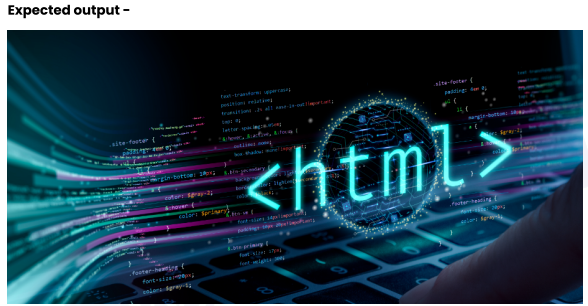

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>🌟 Image Carousel</title>
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            display: flex;
            justify-content: center;
            align-items: center;
            padding: 20px;
        }

        .carousel {
            background: rgba(255, 255, 255, 0.95);
            border-radius: 20px;
            box-shadow: 0 20px 40px rgba(0, 0, 0, 0.3);
            overflow: hidden;
            max-width: 800px;
            width: 100%;
            position: relative;
        }

        .carousel-images {
            position: relative;
            height: 400px;
            overflow: hidden;
        }

        .carousel-image {
            position: absolute;
            top: 0;
            left: 0;
            width: 100%;
            height: 100%;
            object-fit: cover;
            opacity: 0;
            transition: opacity 0.5s ease-in-out;
        }

        .carousel-image.active {
            opacity: 1;
        }

        .carousel-nav {
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 20px 30px;
            background: rgba(0, 0, 0, 0.1);
        }

        .nav-btn {
            background: rgba(255, 255, 255, 0.9);
            border: none;
            width: 50px;
            height: 50px;
            border-radius: 50%;
            font-size: 20px;
            cursor: pointer;
            transition: all 0.3s ease;
            box-shadow: 0 4px 15px rgba(0, 0, 0, 0.2);
        }

        .nav-btn:hover {
            transform: scale(1.1);
            box-shadow: 0 6px 20px rgba(0, 0, 0, 0.3);
        }

        .nav-btn:active {
            transform: scale(0.95);
        }

        .dots-container {
            display: flex;
            gap: 10px;
        }

        .dot {
            width: 12px;
            height: 12px;
            border-radius: 50%;
            background: rgba(255, 255, 255, 0.5);
            border: none;
            cursor: pointer;
            transition: all 0.3s ease;
        }

        .dot.active {
            background: #007bff;
            transform: scale(1.2);
        }

        .carousel-title {
            position: absolute;
            bottom: 20px;
            left: 50%;
            transform: translateX(-50%);
            background: rgba(0, 0, 0, 0.7);
            color: white;
            padding: 10px 20px;
            border-radius: 25px;
            font-size: 1.2em;
            font-weight: bold;
        }

        .autoplay-toggle {
            background: #28a745;
            color: white;
            border: none;
            padding: 8px 16px;
            border-radius: 20px;
            cursor: pointer;
            font-size: 14px;
            transition: all 0.3s ease;
        }

        .autoplay-toggle:hover {
            background: #218838;
        }

        @media (max-width: 600px) {
            .carousel-images {
                height: 250px;
            }
            .carousel-nav {
                padding: 15px 20px;
                flex-direction: column;
                gap: 15px;
            }
        }
    </style>
</head>
<body>
    <div class="carousel" role="region" aria-label="Image carousel">
        <div class="carousel-images" role="list">
            <img src="https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=800&h=400&fit=crop"
                 alt="Mountain landscape at sunset" class="carousel-image active"
                 data-title="🌄 Mountain Sunset">
            <img src="https://images.unsplash.com/photo-1441974231531-c6227db76b6e?w=800&h=400&fit=crop"
                 alt="Ocean waves crashing on rocks" class="carousel-image"
                 data-title="🌊 Ocean Waves">
            <img src="https://images.unsplash.com/photo-1469474968028-56623f02e42e?w=800&h=400&fit=crop"
                 alt="Snowy mountain peak" class="carousel-image"
                 data-title="⛄ Snow Peak">
            <img src="https://images.unsplash.com/photo-1507525428034-b723cf961d3e?w=800&h=400&fit=crop"
                 alt="Beach sunset" class="carousel-image"
                 data-title="🏖️ Beach Sunset">
            <img src="https://images.unsplash.com/photo-1419242902214-272b3f66ee7a?w=800&h=400&fit=crop"
                 alt="Forest path" class="carousel-image"
                 data-title="🌲 Forest Path">
        </div>

        <div class="carousel-title" id="image-title">🌄 Mountain Sunset</div>

        <div class="carousel-nav">
            <button class="nav-btn" id="prev-btn" aria-label="Previous image">‹</button>
            <div class="dots-container" id="dots-container" role="tablist"></div>
            <div>
                <button class="nav-btn" id="next-btn" aria-label="Next image">›</button>
                <button class="autoplay-toggle" id="autoplay-toggle">▶️ Auto-play</button>
            </div>
        </div>
    </div>

    <script>
        class ImageCarousel {
            constructor() {
                this.images = document.querySelectorAll('.carousel-image');
                this.currentIndex = 0;
                this.autoPlayInterval = null;
                this.isAutoPlaying = false;

                this.init();
            }

            init() {
                this.createDots();
                this.bindEvents();
                this.updateCarousel();
            }

            createDots() {
                const dotsContainer = document.getElementById('dots-container');
                this.images.forEach((_, index) => {
                    const dot = document.createElement('button');
                    dot.className = 'dot';
                    dot.setAttribute('aria-label', `Go to image ${index + 1}`);
                    dot.setAttribute('role', 'tab');
                    if (index === 0) dot.classList.add('active');
                    dot.addEventListener('click', () => this.goTo(index));
                    dotsContainer.appendChild(dot);
                });
                this.dots = document.querySelectorAll('.dot');
            }

            bindEvents() {
                document.getElementById('next-btn').addEventListener('click', () => this.next());
                document.getElementById('prev-btn').addEventListener('click', () => this.prev());
                document.getElementById('autoplay-toggle').addEventListener('click', () => this.toggleAutoPlay());

                // Keyboard navigation
                document.addEventListener('keydown', (e) => {
                    if (e.key === 'ArrowRight') this.next();
                    if (e.key === 'ArrowLeft') this.prev();
                });
            }

            updateCarousel() {
                // Update images
                this.images.forEach((img, index) => {
                    img.classList.toggle('active', index === this.currentIndex);
                });

                // Update dots
                this.dots.forEach((dot, index) => {
                    dot.classList.toggle('active', index === this.currentIndex);
                });

                // Update title
                const title = this.images[this.currentIndex].dataset.title;
                document.getElementById('image-title').textContent = title;
            }

            next() {
                this.currentIndex = (this.currentIndex + 1) % this.images.length;
                this.updateCarousel();
                this.pauseAutoPlay();
            }

            prev() {
                this.currentIndex = (this.currentIndex - 1 + this.images.length) % this.images.length;
                this.updateCarousel();
                this.pauseAutoPlay();
            }

            goTo(index) {
                this.currentIndex = index;
                this.updateCarousel();
                this.pauseAutoPlay();
            }

            toggleAutoPlay() {
                if (this.isAutoPlaying) {
                    this.pauseAutoPlay();
                } else {
                    this.startAutoPlay();
                }
            }

            startAutoPlay() {
                this.isAutoPlaying = true;
                document.getElementById('autoplay-toggle').textContent = '⏸️ Pause';
                this.autoPlayInterval = setInterval(() => this.next(), 3000);
            }

            pauseAutoPlay() {
                this.isAutoPlaying = false;
                document.getElementById('autoplay-toggle').textContent = '▶️ Auto-play';
                clearInterval(this.autoPlayInterval);
            }
        }

        // Initialize carousel when page loads
        document.addEventListener('DOMContentLoaded', () => {
            new ImageCarousel();
        });
    </script>
</body>
</html>

Q7. Build a dynamic dropdown menu using HTML and JavaScript. Create an HTML structure for a navigation
menu with dropdowns. Use JavaScript to toggle the visibility of dropdowns when the user hovers over menu
items.
Expected output -

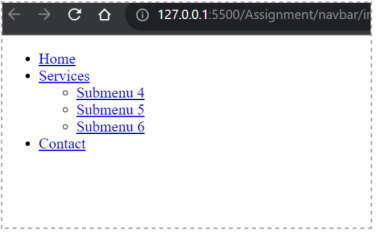

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>🌟 Dynamic Dropdown Menu</title>
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            padding: 20px;
        }

        .navbar {
            background: rgba(255, 255, 255, 0.95);
            backdrop-filter: blur(20px);
            border-radius: 15px;
            box-shadow: 0 10px 30px rgba(0, 0, 0, 0.3);
            overflow: hidden;
            max-width: 1000px;
            margin: 0 auto;
        }

        .nav-container {
            display: flex;
            justify-content: center;
            position: relative;
        }

        .nav-item {
            position: relative;
            list-style: none;
        }

        .nav-link {
            display: block;
            padding: 18px 25px;
            color: #333;
            text-decoration: none;
            font-weight: 600;
            font-size: 16px;
            transition: all 0.3s ease;
            border-radius: 8px;
        }

        .nav-link:hover {
            background: rgba(0, 123, 255, 0.1);
            color: #007bff;
            transform: translateY(-2px);
        }

        /* Dropdown Styles */
        .dropdown {
            position: absolute;
            top: 100%;
            left: 0;
            background: rgba(255, 255, 255, 0.98);
            min-width: 220px;
            box-shadow: 0 10px 30px rgba(0, 0, 0, 0.2);
            border-radius: 10px;
            opacity: 0;
            visibility: hidden;
            transform: translateY(-10px);
            transition: all 0.3s ease;
            list-style: none;
            z-index: 1000;
            overflow: hidden;
            margin-top: 5px;
        }

        .dropdown.active {
            opacity: 1;
            visibility: visible;
            transform: translateY(0);
        }

        .dropdown-item {
            padding: 12px 20px;
            color: #555;
            text-decoration: none;
            display: block;
            transition: all 0.2s ease;
            border-bottom: 1px solid rgba(0, 0, 0, 0.05);
        }

        .dropdown-item:hover {
            background: #007bff;
            color: white;
            padding-left: 25px;
        }

        .dropdown-item:last-child {
            border-bottom: none;
        }

        /* Multi-level dropdown */
        .dropdown .dropdown {
            top: 0;
            left: 100%;
            margin-top: 0;
        }

        /* Mobile Menu */
        .mobile-toggle {
            display: none;
            background: none;
            border: none;
            font-size: 24px;
            cursor: pointer;
            padding: 15px;
            color: #333;
        }

        @media (max-width: 768px) {
            .mobile-toggle {
                display: block;
            }

            .nav-container {
                flex-direction: column;
                display: none;
            }

            .nav-container.active {
                display: flex;
            }

            .dropdown {
                position: static;
                opacity: 1;
                visibility: visible;
                transform: none;
                box-shadow: none;
                background: rgba(0, 0, 0, 0.05);
                margin: 5px 0;
            }
        }

        /* Animations */
        @keyframes slideDown {
            from { opacity: 0; transform: translateY(-10px); }
            to { opacity: 1; transform: translateY(0); }
        }

        .dropdown.active {
            animation: slideDown 0.3s ease-out;
        }
    </style>
</head>
<body>
    <nav class="navbar" role="navigation" aria-label="Main navigation">
        <button class="mobile-toggle" aria-label="Toggle menu" aria-expanded="false">
            ☰
        </button>

        <ul class="nav-container" id="navContainer">
            <li class="nav-item">
                <a href="#" class="nav-link">🏠 Home</a>
            </li>

            <li class="nav-item">
                <a href="#" class="nav-link" data-dropdown="products">🛒 Products</a>
                <ul class="dropdown" id="products">
                    <li><a href="#" class="dropdown-item">📱 Smartphones</a></li>
                    <li><a href="#" class="dropdown-item">💻 Laptops</a></li>
                    <li><a href="#" class="dropdown-item">🎧 Accessories</a></li>
                    <li class="nav-item">
                        <a href="#" class="dropdown-item" data-dropdown="accessories">More...</a>
                        <ul class="dropdown" id="accessories">
                            <li><a href="#" class="dropdown-item">🔋 Batteries</a></li>
                            <li><a href="#" class="dropdown-item">📷 Cameras</a></li>
                            <li><a href="#" class="dropdown-item">💾 Storage</a></li>
                        </ul>
                    </li>
                </ul>
            </li>

            <li class="nav-item">
                <a href="#" class="nav-link" data-dropdown="services">⚙️ Services</a>
                <ul class="dropdown" id="services">
                    <li><a href="#" class="dropdown-item">🛠️ Repairs</a></li>
                    <li><a href="#" class="dropdown-item">📦 Shipping</a></li>
                    <li><a href="#" class="dropdown-item">💳 Payments</a></li>
                </ul>
            </li>

            <li class="nav-item">
                <a href="#" class="nav-link" data-dropdown="about">ℹ️ About</a>
                <ul class="dropdown" id="about">
                    <li><a href="#" class="dropdown-item">👥 Team</a></li>
                    <li><a href="#" class="dropdown-item">🏢 Company</a></li>
                    <li><a href="#" class="dropdown-item">📜 Mission</a></li>
                </ul>
            </li>

            <li class="nav-item">
                <a href="#" class="nav-link">🛒 Cart (0)</a>
            </li>
        </ul>
    </nav>

    <script>
        class DropdownMenu {
            constructor() {
                this.navContainer = document.getElementById('navContainer');
                this.mobileToggle = document.querySelector('.mobile-toggle');
                this.dropdowns = document.querySelectorAll('.dropdown');
                this.navLinks = document.querySelectorAll('.nav-link[data-dropdown]');

                this.init();
            }

            init() {
                this.bindEvents();
                console.log('✅ Dropdown menu initialized');
            }

            bindEvents() {
                // Desktop: Hover events
                this.navLinks.forEach(link => {
                    const dropdownId = link.dataset.dropdown;
                    const dropdown = document.getElementById(dropdownId);

                    // Mouse enter
                    link.addEventListener('mouseenter', () => {
                        this.showDropdown(dropdown);
                    });

                    // Mouse leave
                    link.addEventListener('mouseleave', () => {
                        this.hideDropdown(dropdown);
                    });

                    // Keep dropdown open when hovering over it
                    dropdown.addEventListener('mouseenter', () => {
                        this.showDropdown(dropdown);
                    });

                    dropdown.addEventListener('mouseleave', () => {
                        this.hideDropdown(dropdown);
                    });
                });

                // Mobile menu toggle
                this.mobileToggle.addEventListener('click', () => {
                    this.toggleMobileMenu();
                });

                // Close mobile menu on outside click
                document.addEventListener('click', (e) => {
                    if (!this.navbar.contains(e.target)) {
                        this.navContainer.classList.remove('active');
                        this.mobileToggle.setAttribute('aria-expanded', 'false');
                        this.mobileToggle.textContent = '☰';
                    }
                });
            }

            showDropdown(dropdown) {
                dropdown.classList.add('active');
            }

            hideDropdown(dropdown) {
                dropdown.classList.remove('active');
            }

            toggleMobileMenu() {
                const isActive = this.navContainer.classList.contains('active');

                if (isActive) {
                    this.navContainer.classList.remove('active');
                    this.mobileToggle.setAttribute('aria-expanded', 'false');
                    this.mobileToggle.textContent = '☰';
                } else {
                    this.navContainer.classList.add('active');
                    this.mobileToggle.setAttribute('aria-expanded', 'true');
                    this.mobileToggle.textContent = '✕';
                }
            }
        }

        // Initialize when DOM is loaded
        document.addEventListener('DOMContentLoaded', () => {
            new DropdownMenu();
        });
    </script>
</body>
</html>

Q8. Create a simple dynamic shopping list with the following features
 -  The item should appear in the list?
 -  Each item should be given a button that can be pressed to delete that item off the list?
 -  The input should be emptied and focused ready for you to enter another item

 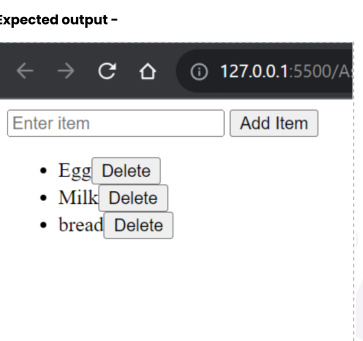

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>🛒 Shopping List</title>
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            padding: 20px;
            display: flex;
            justify-content: center;
            align-items: center;
        }

        .app-container {
            background: rgba(255, 255, 255, 0.95);
            backdrop-filter: blur(20px);
            border-radius: 20px;
            box-shadow: 0 20px 40px rgba(0, 0, 0, 0.3);
            padding: 40px;
            max-width: 500px;
            width: 100%;
        }

        h1 {
            text-align: center;
            color: #333;
            margin-bottom: 30px;
            font-size: 2.5em;
            text-shadow: 2px 2px 4px rgba(0,0,0,0.1);
        }

        .input-section {
            display: flex;
            gap: 10px;
            margin-bottom: 30px;
        }

        #itemInput {
            flex: 1;
            padding: 15px 20px;
            border: 2px solid #e0e0e0;
            border-radius: 50px;
            font-size: 16px;
            outline: none;
            transition: all 0.3s ease;
        }

        #itemInput:focus {
            border-color: #007bff;
            box-shadow: 0 0 20px rgba(0, 123, 255, 0.3);
            transform: scale(1.02);
        }

        #addBtn {
            background: linear-gradient(45deg, #28a745, #20c997);
            color: white;
            border: none;
            padding: 15px 25px;
            border-radius: 50px;
            font-size: 16px;
            font-weight: bold;
            cursor: pointer;
            transition: all 0.3s ease;
            box-shadow: 0 4px 15px rgba(40, 167, 69, 0.4);
        }

        #addBtn:hover {
            transform: translateY(-2px);
            box-shadow: 0 6px 20px rgba(40, 167, 69, 0.6);
        }

        #addBtn:active {
            transform: translateY(0);
        }

        .list-container {
            max-height: 400px;
            overflow-y: auto;
            border-radius: 15px;
            box-shadow: inset 0 2px 10px rgba(0, 0, 0, 0.1);
        }

        .list-container::-webkit-scrollbar {
            width: 8px;
        }

        .list-container::-webkit-scrollbar-track {
            background: rgba(0, 0, 0, 0.1);
            border-radius: 10px;
        }

        .list-container::-webkit-scrollbar-thumb {
            background: #007bff;
            border-radius: 10px;
        }

        #shoppingList {
            list-style: none;
            padding: 0;
        }

        .list-item {
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 18px 25px;
            background: white;
            margin: 8px 15px;
            border-radius: 15px;
            box-shadow: 0 3px 10px rgba(0, 0, 0, 0.1);
            transition: all 0.3s ease;
            animation: slideIn 0.4s ease-out;
        }

        .list-item:hover {
            transform: translateX(5px);
            box-shadow: 0 5px 20px rgba(0, 0, 0, 0.15);
        }

        .item-text {
            font-size: 18px;
            color: #333;
            flex: 1;
        }

        .delete-btn {
            background: linear-gradient(45deg, #dc3545, #c82333);
            color: white;
            border: none;
            padding: 10px 15px;
            border-radius: 50%;
            cursor: pointer;
            font-size: 16px;
            font-weight: bold;
            transition: all 0.3s ease;
            box-shadow: 0 3px 10px rgba(220, 53, 69, 0.4);
            width: 45px;
            height: 45px;
            display: flex;
            align-items: center;
            justify-content: center;
        }

        .delete-btn:hover {
            transform: scale(1.1) rotate(90deg);
            box-shadow: 0 5px 15px rgba(220, 53, 69, 0.6);
        }

        .stats {
            text-align: center;
            margin-top: 20px;
            color: #666;
            font-size: 14px;
        }

        @keyframes slideIn {
            from {
                opacity: 0;
                transform: translateX(-30px);
            }
            to {
                opacity: 1;
                transform: translateX(0);
            }
        }

        @media (max-width: 480px) {
            .app-container {
                padding: 20px;
                margin: 10px;
            }

            h1 {
                font-size: 2em;
            }

            .input-section {
                flex-direction: column;
            }
        }
    </style>
</head>
<body>
    <div class="app-container">
        <h1>🛒 Shopping List</h1>

        <div class="input-section">
            <input
                type="text"
                id="itemInput"
                placeholder="Enter shopping item..."
                maxlength="50"
                autocomplete="off"
            >
            <button id="addBtn">➕ Add Item</button>
        </div>

        <div class="list-container">
            <ul id="shoppingList">
                <!-- Dynamic items appear here -->
            </ul>
        </div>

        <div class="stats" id="stats">
            📊 Add your first item!
        </div>
    </div>

    <script>
        class ShoppingList {
            constructor() {
                this.itemInput = document.getElementById('itemInput');
                this.addBtn = document.getElementById('addBtn');
                this.shoppingList = document.getElementById('shoppingList');
                this.stats = document.getElementById('stats');

                this.items = [];
                this.init();
            }

            init() {
                this.bindEvents();
                this.updateStats();
                this.itemInput.focus(); // Auto-focus on load
            }

            bindEvents() {
                // Add item on button click
                this.addBtn.addEventListener('click', () => this.addItem());

                // Add item on Enter key
                this.itemInput.addEventListener('keypress', (e) => {
                    if (e.key === 'Enter') {
                        this.addItem();
                    }
                });

                // Clear input on Escape
                this.itemInput.addEventListener('keydown', (e) => {
                    if (e.key === 'Escape') {
                        this.itemInput.value = '';
                    }
                });
            }

            addItem() {
                const text = this.itemInput.value.trim();

                if (text === '') {
                    this.shakeInput();
                    return;
                }

                // Create list item
                const li = document.createElement('li');
                li.className = 'list-item';
                li.innerHTML = `
                    <span class="item-text">${this.escapeHtml(text)}</span>
                    <button class="delete-btn" title="Remove item">🗑️</button>
                `;

                // Add delete functionality
                li.querySelector('.delete-btn').addEventListener('click', (e) => {
                    e.stopPropagation();
                    this.removeItem(li);
                });

                // Add to list (beginning for newest first)
                this.shoppingList.insertBefore(li, this.shoppingList.firstChild);
                this.items.unshift(text);

                // Clear and focus input
                this.itemInput.value = '';
                this.itemInput.focus();

                this.updateStats();

                // Visual feedback
                this.flashAddButton();
            }

            removeItem(itemElement) {
                // Animate removal
                itemElement.style.transform = 'translateX(100%)';
                itemElement.style.opacity = '0';

                setTimeout(() => {
                    const text = itemElement.querySelector('.item-text').textContent;
                    const index = this.items.indexOf(text);
                    if (index > -1) {
                        this.items.splice(index, 1);
                    }
                    itemElement.remove();
                    this.updateStats();
                }, 300);
            }

            updateStats() {
                const count = this.items.length;
                if (count === 0) {
                    this.stats.textContent = '📊 Add your first item!';
                } else {
                    this.stats.innerHTML = `📊 ${count} item${count === 1 ? '' : 's'} in your shopping list!`;
                }
            }

            shakeInput() {
                this.itemInput.style.animation = 'shake 0.5s ease-in-out';
                setTimeout(() => {
                    this.itemInput.style.animation = '';
                }, 500);
            }

            flashAddButton() {
                this.addBtn.style.transform = 'scale(0.95)';
                setTimeout(() => {
                    this.addBtn.style.transform = '';
                }, 150);
            }

            escapeHtml(text) {
                const div = document.createElement('div');
                div.textContent = text;
                return div.innerHTML;
            }
        }

        // Initialize app
        document.addEventListener('DOMContentLoaded', () => {
            new ShoppingList();
        });
    </script>

    <style>
        @keyframes shake {
            0%, 100% { transform: translateX(0); }
            25% { transform: translateX(-5px); }
            75% { transform: translateX(5px); }
        }
    </style>
</body>
</html>